# 01 — ARIMA / ARIMAX Baseline

Auto-select ARIMA order, add exogenous covariates (ARIMAX), expanding and rolling 1-step-ahead walk-forward forecasts, sentiment / GS / FRED-daily / COT ablations, Diebold-Mariano significance test, sub-period robustness, and 2026 zoom.

### Roadmap

| § | Step | What happens |
|---|---|---|
| 1 | Load features | Read `train/val/test.csv`, resample to W-FRI (`.sum()` for log-returns, `.last()` for level features like `gs_ratio_z`), build the train+val refit sample and the lagged EXOG matrix. |
| 2 | Order selection (AIC) | Grid-search $(p,0,q)$ for $p,q \in \{0,\dots,5\}$ on train+val. AIC picks $(0,0,0)$ — weekly silver returns have no usable linear autocorrelation, so ARIMAX reduces to OLS on lagged regressors. |
| 3 | Forecast schemes + walk-forward | Define `recursive_forecast` (expanding window) and `rolling_forecast` (last 100 weeks). Both refit the model at every step. Run ARIMA with each window. |
| 4 | ARIMAX | Same walk-forward but with the 6 lagged cross-asset returns (`gold, usd, copper, sp500, vix, oil`) as exogenous regressors. `gs_ratio_z` is held out as a separate ablation group for §7. |
| 5 | Evaluate | RMSE / MAE / DA / WDA for Naïve, ARIMA (both windows), ARIMAX (both windows). Save `metrics_arima.csv`. |
| 6 | Predicted vs actual | Two-panel time-series plot of test-set predictions vs realised weekly returns. |
| 7 | Ablation ladder | Re-run rolling ARIMAX adding each public-information group (read from `feature_groups.json`) as extra lagged exog: GS, FRED-daily, COT, Reddit, News, Sentiment, Macro+COT, GS+Sentiment, ALL. |
| 8 | Sub-period robustness | Pick the best variant by WDA (separately for pure ARIMA and ARIMAX), break DA/WDA down by `PERIODS`, save `period_*_weekly.csv` and `preds_*_best_weekly.csv` for cross-model DM tests in `evaluation.ipynb`. |
| 9 | Diebold-Mariano | Each §7 variant vs `ARIMAX rolling (100w)` baseline under squared-error loss, Newey-West lag-1 — tests whether any public-information group delivers a *significant* improvement (semi-strong-form efficiency check). |
| 10 | 2026 zoom | Actual vs best variant on the 2026 YTD slice, where silver has been most active. |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120

## 1. Load features

In [2]:
# Weekly feature frame (built once by 02_features.ipynb §8 — single source of truth).
weekly = pd.read_csv('../../data/processed/features_weekly.csv', index_col=0, parse_dates=True)

TARGET       = 'silver_return'
EXOG_RETURNS = ['gold_return', 'usd_return', 'copper_return',
                'sp500_return', 'vix_return', 'oil_return']
EXOG_LEVELS  = ['gs_ratio_z']   # level features — weekly resample uses .last(), not .sum()

# Weekly target per split (already W-FRI-summed in the frame).
def _y(name): return weekly.loc[weekly['split'] == name, TARGET].dropna()
y_train, y_val, y_test = _y('train'), _y('val'), _y('test')
# Refit on train+val before predicting test (val already used for model selection),
# so walk-forward starts end-2022 rather than end-2021.
y_train_full = pd.concat([y_train, y_val]).sort_index()

ret_cols  = EXOG_RETURNS
lvl_cols  = EXOG_LEVELS
exog_cols = ret_cols + lvl_cols

# Weekly exog per split (un-lagged; the 1-week lag is applied in §4). Returns are
# W-FRI-summed and gs_ratio_z is Friday-close in the frame — no re-aggregation here.
def _exog(name): return weekly.loc[weekly['split'] == name, exog_cols]
train_w, val_w, test_w = _exog('train'), _exog('val'), _exog('test')
trainval_w = pd.concat([train_w, val_w]).sort_index()  # combined exog for refit stage

print(f'Weekly train: {len(y_train)} weeks | val: {len(y_val)} | '
      f'train+val: {len(y_train_full)} | test: {len(y_test)}')
print(f'EXOG columns: {exog_cols}')

Weekly train: 365 weeks | val: 52 | train+val: 417 | test: 174
EXOG columns: ['gold_return', 'usd_return', 'copper_return', 'sp500_return', 'vix_return', 'oil_return', 'gs_ratio_z']


### Why aggregate to weekly?

**Log returns are additive**, so summing 5 daily log-returns gives the exact weekly log-return:

$$\log\frac{P_5}{P_1} = \log\frac{P_2}{P_1} + \log\frac{P_3}{P_2} + \log\frac{P_4}{P_3} + \log\frac{P_5}{P_4}$$

No approximation is involved — this is exact. The same applies to the exogenous market returns.

**Sentiment** is aggregated with `.mean()` instead of `.sum()` — we want the average mood
over the week, not an accumulated score. Sentiment values are bounded in $[-1, 1]$ so summing
them would produce an unbounded number with no clear interpretation.

**Shape after aggregation:**

| Split | Daily | Weekly |
|-------|-------|--------|
| Train | 1 755 rows | ~351 weeks |
| Test  |   500 rows | ~100 weeks |

The 100-week test set is the binding constraint — it is enough for a meaningful evaluation
but directional accuracy estimates will have wider confidence intervals than the daily version.
See `03b_arima_daily.ipynb` for the 1-day-ahead version on the full daily sample.

TODO: remove the daily mention if we don't get to the daily part.

## 2. Order selection via AIC grid search

In [3]:
best_aic, best_order = np.inf, (1, 0, 1)
results = []

# AIC selection on train+val combined — val is part of "selection data",
# not test, so it's appropriate to include here. With (0,0,0) winning by a
# wide margin the order is robust to whether val is included, but using the
# combined sample is the cleaner methodological choice.
for p in range(0, 6):
    for q in range(0, 6):
        try:
            m = ARIMA(y_train_full, order=(p, 0, q)).fit()
            results.append({'p': p, 'q': q, 'aic': m.aic, 'bic': m.bic})
            if m.aic < best_aic:
                best_aic, best_order = m.aic, (p, 0, q)
        except Exception:
            pass

results_df = pd.DataFrame(results).sort_values('aic').head(10)
print(f'Best ARIMA order (weekly, train+val): {best_order}  AIC: {best_aic:.2f}')
results_df

Best ARIMA order (weekly, train+val): (0, 0, 0)  AIC: -1533.42


,p,q,aic,bic
0,0,0,-1533.424232,-1525.358060
1,0,1,-1531.610018,-1519.510759
6,1,0,-1531.606538,-1519.507280
7,1,1,-1531.334543,-1515.202198
14,2,2,-1530.130913,-1505.932395
24,4,0,-1529.848070,-1505.649553
4,0,4,-1529.668537,-1505.470019
2,0,2,-1529.663834,-1513.531489
12,2,0,-1529.637864,-1513.505520
3,0,3,-1528.598482,-1508.433051


> **Note — ARIMAX(0,0,0) is OLS regression**
>
> Because the AIC search selects order (0,0,0), the ARIMAX model below reduces to
> ordinary least squares on lagged exogenous variables.  This is expected for weekly
> silver returns — there is almost no linear autocorrelation once noise is factored in.
> The value of ARIMAX here is the formal framework for testing whether macro covariates
> add predictive power, not the AR/MA terms themselves.

## 3. Forecast schemes — motivation

**Train+val refit before testing.** Val (2022) is used implicitly via AIC order
selection on the combined sample (see cell above). Once the order is chosen,
walk-forward starts from `y_train_full = train + val` so that week 1 of the
test set (early Jan 2023) sees the full preceding history including 2022 —
not just up to end-2021. This matches the standard ML pattern (train → val for
selection → refit on train+val before test).

Two approaches for generating 1-step-ahead out-of-sample forecasts:

**Expanding window (recursive)**  — trains on *all* available history up to week *t*.
- Pros: uses maximum data; asymptotically efficient.
- Cons: old regimes (pre-2021 silver squeeze) have equal weight as recent ones.

**Rolling window (100 weeks ≈ 2 years)** — trains on the *most recent* 100 weeks only.
- Pros: adapts faster to regime changes; silver has had at least two distinct volatility regimes.
- Cons: discards long-run information.

Both are run and compared. For ARIMAX we only use the rolling window in the sentiment comparison (lower memory, faster re-estimation).

## 3. Walk-forward forecast functions

In [4]:
def recursive_forecast(y_train, y_test, order, exog_train=None, exog_test=None):
    """Expanding-window 1-step-ahead forecast."""
    history = list(y_train)
    preds   = []
    exog_h  = list(exog_train.values) if exog_train is not None else None

    for t in range(len(y_test)):
        exog_f = [exog_test.iloc[t].values] if exog_h is not None else None
        try:
            model = ARIMA(history, order=order,
                          exog=exog_h if exog_h is not None else None).fit()
            fc = model.forecast(steps=1, exog=exog_f)
            preds.append(float(np.asarray(fc).flat[0]))
        except Exception:
            preds.append(np.nan)
        history.append(float(y_test.iloc[t]))
        if exog_h is not None:
            exog_h.append(exog_test.iloc[t].values)
    return np.array(preds)


def rolling_forecast(y_train, y_test, order, window_size=100,
                     exog_train=None, exog_test=None):
    """Fixed-window 1-step-ahead forecast (most recent window_size weeks)."""
    history = list(y_train[-window_size:])
    preds   = []
    exog_h  = list(exog_train.values[-window_size:]) if exog_train is not None else None

    for t in range(len(y_test)):
        exog_f = [exog_test.iloc[t].values] if exog_h is not None else None
        try:
            model = ARIMA(history, order=order,
                          exog=exog_h if exog_h is not None else None).fit()
            fc = model.forecast(steps=1, exog=exog_f)
            preds.append(float(np.asarray(fc).flat[0]))
        except Exception:
            preds.append(np.nan)
        history.append(float(y_test.iloc[t]))
        history.pop(0)
        if exog_h is not None:
            exog_h.append(exog_test.iloc[t].values)
            exog_h.pop(0)
    return np.array(preds)

In [5]:
print('Running ARIMA expanding window (weekly, train+val refit)...')
preds_arima_exp = recursive_forecast(y_train_full, y_test, best_order)
print('Running ARIMA rolling window (100 weeks)...')
preds_arima_rol = rolling_forecast(y_train_full, y_test, best_order, window_size=100)
print('Done')

Running ARIMA expanding window (weekly, train+val refit)...


Running ARIMA rolling window (100 weeks)...


Done


## 4. ARIMAX — add exogenous variables

Exogenous variables: `gold_return`, `usd_return`, `copper_return`, `sp500_return`, `vix_return`, `oil_return`.

**Lookahead fix** — at week *t* we don't know this week's macro returns until the week closes, so every exogenous variable is lagged by 1 week before it enters the model.

Implementation: concat train+val and test into one frame, then `.shift(1)` once. The shift naturally puts the last train+val row's value into the first test row, so the val→test boundary is handled by pandas — no manual `iloc[[-1]]` / `ignore_index=True` trick. Same pattern as `04_random_forest.ipynb` / `05_xgboost.ipynb`.

In [6]:
# ── Feature groups for ablation ─────────────────────────────────────────────
# Baseline ARIMAX uses returns-only EXOG. gs_ratio_z is a separate group
# tested as an ablation in §7 (+GS variants).
exog_cols = ret_cols                 # returns-only baseline
gs_cols   = lvl_cols                 # gs_ratio_z (added in +GS variants)
print(f'Baseline EXOG (returns): {exog_cols}')
print(f'GS group (level):        {gs_cols}')

# Lag exog by 1 week via .shift(1) on the concatenated train+val+test frame.
all_exog_lag   = pd.concat([trainval_w, test_w]).shift(1).fillna(0) # Asier: check this fillna is sensible
X_trainval_lag = all_exog_lag.loc[y_train_full.index, exog_cols]
X_test_lag     = all_exog_lag.loc[y_test.index,       exog_cols]

print('Running ARIMAX expanding window (weekly, lagged exog, train+val refit)...')
preds_arimax_exp = recursive_forecast(y_train_full, y_test, best_order,
                                      exog_train=X_trainval_lag, exog_test=X_test_lag)
print('Running ARIMAX rolling window (100 weeks, lagged exog)...')
preds_arimax_rol = rolling_forecast(y_train_full, y_test, best_order, window_size=100,
                                    exog_train=X_trainval_lag, exog_test=X_test_lag)
print('Done')

Baseline EXOG (returns): ['gold_return', 'usd_return', 'copper_return', 'sp500_return', 'vix_return', 'oil_return']
GS group (level):        ['gs_ratio_z']
Running ARIMAX expanding window (weekly, lagged exog, train+val refit)...


Running ARIMAX rolling window (100 weeks, lagged exog)...


Done


## 5. Evaluate

In [7]:
import sys, os
sys.path.insert(0, os.path.abspath('../../src'))
from eval_utils import evaluate, period_metrics, diebold_mariano, PERIODS

actuals    = y_test.values
test_index = y_test.index

naive_pred = np.concatenate([[np.nan], actuals[:-1]])

metrics = []
metrics.append(evaluate('Naive (t-1 week)',           actuals, naive_pred))
metrics.append(evaluate('ARIMA expanding',            actuals, preds_arima_exp))
metrics.append(evaluate('ARIMA rolling (100w)',       actuals, preds_arima_rol))
metrics.append(evaluate('ARIMAX expanding',           actuals, preds_arimax_exp))
metrics.append(evaluate('ARIMAX rolling (100w)',      actuals, preds_arimax_rol))

metrics_df = pd.DataFrame([m for m in metrics if m is not None])
metrics_df.to_csv('../../data/processed/metrics_arima.csv', index=False)
metrics_df

Naive (t-1 week)                               RMSE=0.07594  MAE=0.05397  DA=0.491  WDA=0.490
ARIMA expanding                                RMSE=0.05190  MAE=0.03714  DA=0.557  WDA=0.588
ARIMA rolling (100w)                           RMSE=0.05174  MAE=0.03690  DA=0.557  WDA=0.573
ARIMAX expanding                               RMSE=0.05220  MAE=0.03683  DA=0.569  WDA=0.555
ARIMAX rolling (100w)                          RMSE=0.05323  MAE=0.03765  DA=0.523  WDA=0.483


,model,rmse,mae,dir_acc,wda
0,Naive (t-1 week),0.075941,0.053966,0.491329,0.489862
1,ARIMA expanding,0.051903,0.037135,0.557471,0.587779
2,ARIMA rolling (100w),0.051745,0.036896,0.557471,0.572523
3,ARIMAX expanding,0.052196,0.036835,0.568966,0.554856
4,ARIMAX rolling (100w),0.053226,0.037650,0.522989,0.482664


## 6. Predicted vs actual

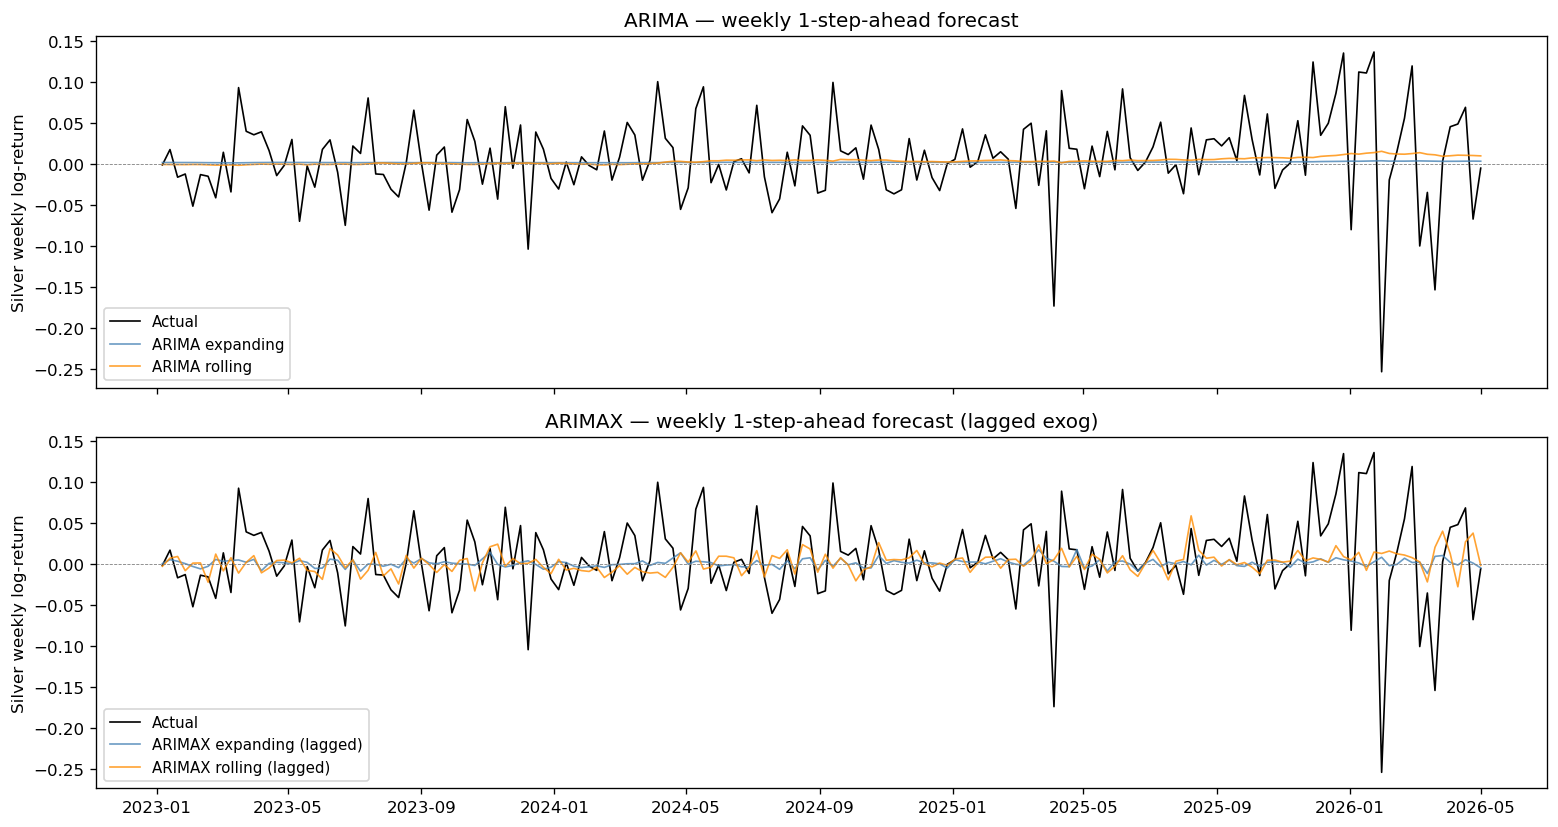

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(test_index, actuals,          label='Actual',           lw=1, color='black')
axes[0].plot(test_index, preds_arima_exp,  label='ARIMA expanding',  lw=1, alpha=0.8, color='steelblue')
axes[0].plot(test_index, preds_arima_rol,  label='ARIMA rolling',    lw=1, alpha=0.8, color='darkorange')
axes[0].axhline(0, color='grey', lw=0.5, ls='--')
axes[0].set_title('ARIMA — weekly 1-step-ahead forecast')
axes[0].set_ylabel('Silver weekly log-return')
axes[0].legend(fontsize=9)

axes[1].plot(test_index, actuals,           label='Actual',                   lw=1, color='black')
axes[1].plot(test_index, preds_arimax_exp,  label='ARIMAX expanding (lagged)', lw=1, alpha=0.8, color='steelblue')
axes[1].plot(test_index, preds_arimax_rol,  label='ARIMAX rolling (lagged)',   lw=1, alpha=0.8, color='darkorange')
axes[1].axhline(0, color='grey', lw=0.5, ls='--')
axes[1].set_title('ARIMAX — weekly 1-step-ahead forecast (lagged exog)')
axes[1].set_ylabel('Silver weekly log-return')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

**Reading the plots.** ARIMA(0,0,0) reduces to the conditional mean: a near-flat line close to zero (slightly positive — the unconditional weekly drift). Both windows look nearly identical, because the only thing they're predicting is that mean.

ARIMAX shows visible week-to-week variation as the lagged exog regressors move. **Expanding window** stays close to zero — coefficients are anchored by the full 400+ week history, so any one week's exog only nudges the forecast a little. **Rolling (100w)** moves further from zero — the smaller, more recent sample lets the coefficients respond more aggressively to recent macro moves, at the cost of more noise.

## 7. Ablation ladder

Re-runs ARIMAX rolling (100 weeks), adding each **public-information group** as extra lagged
exogenous variables on top of the returns-only EXOG baseline. Groups are read from
`feature_groups.json` (built in `02_features`), so the ladder tracks the feature set
automatically. Every extra is lagged 1 week — same look-ahead discipline as the baseline
returns.

Variants (on top of the 6 cross-asset returns):

- **GS** — `gs_ratio_z`, standardised gold/silver ratio (valuation / mean-reversion)
- **FRED_daily** — Δ 10y real rate, Δ 10y breakeven, Δlog initial jobless claims (rates + activity)
- **COT** — Managed-Money and Commercial net positioning (% of open interest)
- **Reddit / News / Sentiment** — weekly-mean Twitter-RoBERTa, FinBERT, and both together
- **Macro+COT** — the hard-data macro + positioning bundle (FRED_daily + COT)
- **GS + Sentiment**
- **ALL** — GS + FRED_daily + COT + Sentiment (kitchen sink)

Each is a semi-strong-form-efficiency test: does adding that public channel beat the
returns-only baseline? FRED *monthly* macro is tested separately in
`02_features` §8 / `03_midas`, so it is not duplicated here.

In [9]:
import json

# Ablation groups come from 02_features' feature_groups.json so the ladder tracks the
# feature set automatically. ARIMAX baseline = YF_DAILY returns (ret_cols).
with open('../../data/processed/feature_groups.json') as f:
    GROUPS = json.load(f)

all_candidates = {
    'ARIMAX expanding':      preds_arimax_exp,
    'ARIMAX rolling (100w)': preds_arimax_rol,
}

# Every ablation column is already weekly-aggregated in the frame (returns / Delta-changes
# -> sum, levels / net-% positioning -> last, sentiment -> mean). Select + apply the 1-week
# lag — same discipline as the baseline EXOG.
ABLATION_COLS = GROUPS['YF_DAILY'] + GROUPS['FRED_DAILY'] + GROUPS['GS'] + GROUPS['COT'] + GROUPS['SENT']
all_feat_lag  = weekly[ABLATION_COLS].shift(1).fillna(0)

def make_exog(extra):
    cols = ret_cols + [c for c in extra if c in all_feat_lag.columns]
    return all_feat_lag.loc[y_train_full.index, cols], all_feat_lag.loc[y_test.index, cols]

# Ladder: each public-information group on the returns baseline, plus sensible combos.
LADDER = [
    ('GS',           GROUPS['GS']),
    ('FRED_daily',   GROUPS['FRED_DAILY']),
    ('COT',          GROUPS['COT']),
    ('Reddit',       ['reddit_sentiment']),
    ('News',         ['news_sentiment']),
    ('Sentiment',    GROUPS['SENT']),
    ('Macro+COT',    GROUPS['FRED_DAILY'] + GROUPS['COT']),
    ('GS+Sentiment', GROUPS['GS'] + GROUPS['SENT']),
    ('ALL',          GROUPS['GS'] + GROUPS['FRED_DAILY'] + GROUPS['COT'] + GROUPS['SENT']),
]

for label, extra in LADDER:
    X_tr, X_te = make_exog(extra)
    print(f'Running ARIMAX+{label} rolling (100w)...')
    all_candidates[f'ARIMAX+{label} rolling (100w)'] = rolling_forecast(
        y_train_full, y_test, best_order, window_size=100, exog_train=X_tr, exog_test=X_te)

print('\nAll variants (RMSE / MAE / DA / WDA):')
for name, pred in all_candidates.items():
    evaluate(name, actuals, pred)

Running ARIMAX+GS rolling (100w)...


Running ARIMAX+FRED_daily rolling (100w)...


Running ARIMAX+COT rolling (100w)...


Running ARIMAX+Reddit rolling (100w)...


Running ARIMAX+News rolling (100w)...


Running ARIMAX+Sentiment rolling (100w)...


Running ARIMAX+Macro+COT rolling (100w)...


Running ARIMAX+GS+Sentiment rolling (100w)...


Running ARIMAX+ALL rolling (100w)...



All variants (RMSE / MAE / DA / WDA):
ARIMAX expanding                               RMSE=0.05220  MAE=0.03683  DA=0.569  WDA=0.555
ARIMAX rolling (100w)                          RMSE=0.05323  MAE=0.03765  DA=0.523  WDA=0.483
ARIMAX+GS rolling (100w)                       RMSE=0.05450  MAE=0.03767  DA=0.580  WDA=0.573
ARIMAX+FRED_daily rolling (100w)               RMSE=0.05371  MAE=0.03787  DA=0.557  WDA=0.512
ARIMAX+COT rolling (100w)                      RMSE=0.05468  MAE=0.03831  DA=0.586  WDA=0.589
ARIMAX+Reddit rolling (100w)                   RMSE=0.05376  MAE=0.03808  DA=0.529  WDA=0.502
ARIMAX+News rolling (100w)                     RMSE=0.05332  MAE=0.03745  DA=0.557  WDA=0.544
ARIMAX+Sentiment rolling (100w)                RMSE=0.05387  MAE=0.03786  DA=0.552  WDA=0.532
ARIMAX+Macro+COT rolling (100w)                RMSE=0.05517  MAE=0.03831  DA=0.626  WDA=0.624
ARIMAX+GS+Sentiment rolling (100w)             RMSE=0.05506  MAE=0.03821  DA=0.557  WDA=0.532
ARIMAX+ALL rolling (1

## 8. Sub-period robustness: DA and WDA by year

Breaks down the best-performing variant by calendar year to check whether
directional accuracy is stable or driven by one lucky period.

In [10]:
def _best_by_wda(candidates, actuals):
    return max(candidates, key=lambda k:
        np.nansum(np.abs(actuals) * (np.sign(actuals) == np.sign(candidates[k]))) /
        np.nansum(np.abs(actuals)))

# Best pure ARIMA (no exogenous)
arima_only      = {'ARIMA expanding': preds_arima_exp, 'ARIMA rolling (100w)': preds_arima_rol}
best_arima_name = _best_by_wda(arima_only, actuals)
print('Best ARIMA by WDA:', best_arima_name)
res_arima = period_metrics(actuals, arima_only[best_arima_name], test_index, PERIODS)
display(res_arima[['n', 'DA', 'WDA']].style
        .format({'n': '{:.0f}', 'DA': '{:.3f}', 'WDA': '{:.3f}'})
        .background_gradient(cmap='RdYlGn', subset=['DA', 'WDA'], vmin=0.4, vmax=0.7))
res_arima[['n', 'DA', 'WDA']].to_csv('../../data/processed/period_arima_weekly.csv')

# Best ARIMAX variant (includes GS / FRED-daily / COT / sentiment extensions in all_candidates)
best_arimax_name = _best_by_wda(all_candidates, actuals)
best_pred        = all_candidates[best_arimax_name]
print('\nBest ARIMAX by WDA:', best_arimax_name)
res_arimax = period_metrics(actuals, best_pred, test_index, PERIODS)
display(res_arimax[['n', 'DA', 'WDA']].style
        .format({'n': '{:.0f}', 'DA': '{:.3f}', 'WDA': '{:.3f}'})
        .background_gradient(cmap='RdYlGn', subset=['DA', 'WDA'], vmin=0.4, vmax=0.7))
res_arimax[['n', 'DA', 'WDA']].to_csv('../../data/processed/period_arimax_weekly.csv')

# Save winning variant predictions for cross-model DM tests in evaluation.ipynb
# (both the best pure-ARIMA and best-ARIMAX winners — these feed the cross-model
#  pairwise DM matrix in §12 of evaluation.ipynb.)
pd.DataFrame({'actual': actuals, 'predicted': arima_only[best_arima_name]}, index=test_index)\
  .rename_axis('Date').to_csv('../../data/processed/preds_arima_best_weekly.csv')
pd.DataFrame({'actual': actuals, 'predicted': best_pred}, index=test_index)\
  .rename_axis('Date').to_csv('../../data/processed/preds_arimax_best_weekly.csv')
print(f'\nSaved: preds_arima_best_weekly.csv  ({best_arima_name})')
print(f'Saved: preds_arimax_best_weekly.csv  ({best_arimax_name})')

Best ARIMA by WDA: ARIMA expanding


,n,DA,WDA
Period,,,
2023 (choppy),52,0.481,0.492
2024 (bull start),52,0.500,0.570
2025 (bull run),52,0.692,0.757
2026 (YTD),18,0.556,0.498
── Full test ──,174,0.557,0.588



Best ARIMAX by WDA: ARIMAX+Macro+COT rolling (100w)


,n,DA,WDA
Period,,,
2023 (choppy),52,0.615,0.612
2024 (bull start),52,0.615,0.551
2025 (bull run),52,0.673,0.798
2026 (YTD),18,0.556,0.488
── Full test ──,174,0.626,0.624



Saved: preds_arima_best_weekly.csv  (ARIMA expanding)
Saved: preds_arimax_best_weekly.csv  (ARIMAX+Macro+COT rolling (100w))


## 9. Diebold-Mariano test

Tests whether each public-information variant produces a statistically significant forecast
improvement over the no-extras ARIMAX rolling baseline.

**H0**: equal predictive accuracy (squared error loss).  
A negative DM statistic means the baseline has *larger* errors (challenger is better).  
Newey-West variance correction with lag=1 for weekly autocorrelation.

# Asier: understand the comment of Newest-West

In [11]:
print('Diebold-Mariano tests -- each variant vs ARIMAX rolling (no sentiment)')
print('H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns=not significant')
print('-' * 95)

baseline_key  = 'ARIMAX rolling (100w)'
baseline_pred = all_candidates[baseline_key]
for name, pred in all_candidates.items():
    if name == baseline_key:
        continue
    diebold_mariano(actuals, baseline_pred, pred, baseline_key, name)

Diebold-Mariano tests -- each variant vs ARIMAX rolling (no sentiment)
H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns=not significant
-----------------------------------------------------------------------------------------------
ARIMAX rolling (100w)                    vs ARIMAX expanding                          DM=+1.732  p=0.083  (ns)  -> winner: tie
ARIMAX rolling (100w)                    vs ARIMAX+GS rolling (100w)                  DM=-1.005  p=0.315  (ns)  -> winner: tie
ARIMAX rolling (100w)                    vs ARIMAX+FRED_daily rolling (100w)          DM=-0.936  p=0.349  (ns)  -> winner: tie
ARIMAX rolling (100w)                    vs ARIMAX+COT rolling (100w)                 DM=-0.799  p=0.424  (ns)  -> winner: tie
ARIMAX rolling (100w)                    vs ARIMAX+Reddit rolling (100w)              DM=-1.930  p=0.054  (ns)  -> winner: tie
ARIMAX rolling (100w)                    vs ARIMAX+News rolling (100w)                DM=-0.175  p=0.861  (ns) 

## 10. 2026 zoom — actual vs best model

Focuses on the most recent out-of-sample period where silver has been most active.

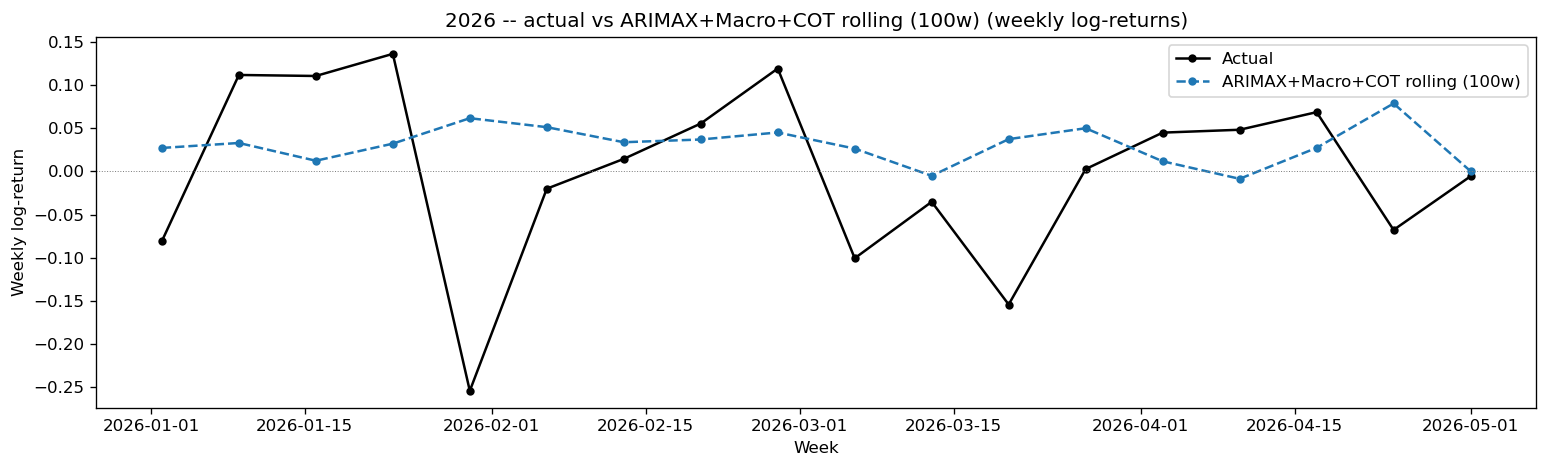

In [12]:
df26 = pd.DataFrame({'actual': actuals, 'pred': best_pred}, index=test_index)
df26 = df26.loc['2026':]

if df26.empty:
    print('No 2026 data in test set yet.')
else:
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(df26.index, df26['actual'], color='black',   lw=1.5, marker='o', ms=4, label='Actual')
    ax.plot(df26.index, df26['pred'],   color='#1f77b4', lw=1.5, marker='o', ms=4,
            ls='--', label=best_arimax_name)
    ax.axhline(0, color='grey', lw=0.6, ls=':')
    ax.set_title('2026 -- actual vs {} (weekly log-returns)'.format(best_arimax_name), fontsize=12)
    ax.set_ylabel('Weekly log-return')
    ax.set_xlabel('Week')
    ax.legend()
    plt.tight_layout()
    plt.show()